# Trust Region Policy Optimization (TRPO)

**Paper:** [Trust Region Policy Optimization](https://arxiv.org/abs/1502.05477) (Schulman et al., ICML 2015)

This notebook implements TRPO from scratch in PyTorch, training a policy on CartPole-v1.
The core algorithm:
1. Collect on-policy trajectories and compute GAE advantages
2. Compute the surrogate (policy gradient) objective
3. Solve the constrained optimization: maximize surrogate s.t. KL(old || new) ≤ δ
4. Use conjugate gradient + Fisher-vector products + backtracking line search


## 1. Setup & Imports

In [1]:
import torch

import torch.nn as nn

import torch.optim as optim

import numpy as np

import gymnasium as gym

import matplotlib.pyplot as plt

from collections import deque

import warnings

warnings.filterwarnings('ignore')



# Set seeds for reproducibility

SEED = 42

torch.manual_seed(SEED)

np.random.seed(SEED)



device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cpu


## 2. Environment: CartPole-v1We use CartPole-v1 — a classic control task with a discrete action space.- Observation (4-dim): cart position, cart velocity, pole angle, pole angular velocity- Actions (2): push left (0) or push right (1)- Reward: +1 per timestep alive; max episode length = 500

In [2]:
env = gym.make('CartPole-v1')

obs_dim = env.observation_space.shape[0]  # 4

n_actions = env.action_space.n             # 2

print(f'Observation dim: {obs_dim}, Actions: {n_actions}')



obs, info = env.reset(seed=SEED)

print(f'Initial obs: {obs}')

Observation dim: 4, Actions: 2
Initial obs: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## 3. Policy Network (Actor)A small MLP that outputs a softmax distribution over actions.

In [3]:
class PolicyNetwork(nn.Module):

    def __init__(self, obs_dim, n_actions, hidden=64):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(obs_dim, hidden),

            nn.Tanh(),

            nn.Linear(hidden, hidden),

            nn.Tanh(),

            nn.Linear(hidden, n_actions)

        )

    

    def forward(self, x):

        logits = self.net(x)

        return logits  # raw logits; apply softmax for probabilities

    

    def get_action(self, obs):

        """Sample an action and return (action, log_prob, entropy, value_placeholder)."""

        x = torch.FloatTensor(obs).unsqueeze(0).to(device)

        logits = self.forward(x)

        probs = torch.softmax(logits, dim=-1)

        dist = torch.distributions.Categorical(probs)

        action = dist.sample()

        log_prob = dist.log_prob(action)

        entropy = dist.entropy()

        return action.item(), log_prob, entropy

    

    def get_log_probs_and_entropy(self, obs, actions):

        """Batched: compute log_probs and entropy for given states and actions."""

        logits = self.forward(obs)

        probs = torch.softmax(logits, dim=-1)

        dist = torch.distributions.Categorical(probs)

        log_probs = dist.log_prob(actions)

        entropy = dist.entropy()

        return log_probs, entropy, probs



policy = PolicyNetwork(obs_dim, n_actions).to(device)

print(f'Policy parameters: {sum(p.numel() for p in policy.parameters())}')

Policy parameters: 4610


## 4. Value Network (Critic)A small MLP that estimates V(s) — used for advantage computation and as a baseline.

In [4]:
class ValueNetwork(nn.Module):

    def __init__(self, obs_dim, hidden=64):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(obs_dim, hidden),

            nn.Tanh(),

            nn.Linear(hidden, hidden),

            nn.Tanh(),

            nn.Linear(hidden, 1)

        )

    

    def forward(self, x):

        return self.net(x).squeeze(-1)  # (batch,)



value_fn = ValueNetwork(obs_dim).to(device)

value_optimizer = optim.Adam(value_fn.parameters(), lr=1e-3)

print(f'Value function parameters: {sum(p.numel() for p in value_fn.parameters())}')

Value function parameters: 4545


## 5. Trajectory Collection & GAE AdvantagesCollect on-policy trajectories using the current policy, then compute:- **Returns-to-go:** R_t = Σ γ^k r_{t+k}- **GAE advantages:** A_t = Σ (γλ)^k δ_{t+k} where δ_t = r_t + γV(s_{t+1}) - V(s_t)GAE reduces variance vs raw Monte Carlo returns by blending TD and MC estimates.

In [5]:
def collect_trajectories(env, policy, value_fn, batch_size=2000, gamma=0.99, lam=0.95):

    """Collect trajectories until we have batch_size timesteps."""

    states, actions, rewards, dones, old_log_probs, values = [], [], [], [], [], []

    ep_rewards = []

    

    obs, _ = env.reset(seed=np.random.randint(0, 100000))

    ep_reward = 0

    

    while len(states) < batch_size:

        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)

        

        # Get action from policy

        with torch.no_grad():

            logits = policy(obs_t)

            probs = torch.softmax(logits, dim=-1)

            dist = torch.distributions.Categorical(probs)

            action = dist.sample()

            log_prob = dist.log_prob(action)

            

            v = value_fn(obs_t)

        

        next_obs, reward, terminated, truncated, _ = env.step(action.item())

        done = terminated or truncated

        

        states.append(obs)

        actions.append(action.item())

        rewards.append(reward)

        dones.append(done)

        old_log_probs.append(log_prob.item())

        values.append(v.item())

        

        ep_reward += reward

        obs = next_obs

        

        if done:

            ep_rewards.append(ep_reward)

            ep_reward = 0

            obs, _ = env.reset(seed=np.random.randint(0, 100000))

    

    states = np.array(states[:batch_size])

    actions = np.array(actions[:batch_size])

    rewards = np.array(rewards[:batch_size])

    dones = np.array(dones[:batch_size])

    old_log_probs = np.array(old_log_probs[:batch_size])

    values = np.array(values[:batch_size])

    

    # Compute returns-to-go and GAE advantages

    returns = np.zeros_like(rewards)

    advantages = np.zeros_like(rewards)

    

    gae = 0

    for t in reversed(range(len(rewards))):

        if t == len(rewards) - 1:

            next_value = 0.0

        else:

            next_value = values[t + 1] * (1 - dones[t])

        

        delta = rewards[t] + gamma * next_value - values[t]

        gae = delta + gamma * lam * (1 - dones[t]) * gae

        advantages[t] = gae

        

        returns[t] = advantages[t] + values[t]

    

    # Standardize advantages

    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    

    return {

        'states': torch.FloatTensor(states).to(device),

        'actions': torch.LongTensor(actions).to(device),

        'rewards': rewards,

        'dones': dones,

        'old_log_probs': torch.FloatTensor(old_log_probs).to(device),

        'advantages': torch.FloatTensor(advantages).to(device),

        'returns': torch.FloatTensor(returns).to(device),

        'ep_rewards': ep_rewards

    }



# Quick test

batch = collect_trajectories(env, policy, value_fn, batch_size=500)

print(f'Collected {len(batch["states"])} timesteps, {len(batch["ep_rewards"])} episodes')

print(f'Avg episode reward: {np.mean(batch["ep_rewards"]):.1f}')

print(f'States shape: {batch["states"].shape}, Advantages shape: {batch["advantages"].shape}')

Collected 500 timesteps, 27 episodes
Avg episode reward: 17.9
States shape: torch.Size([500, 4]), Advantages shape: torch.Size([500])


## 6. TRPO Core: Surrogate Loss, KL Divergence, Fisher-Vector ProductThe three core functions of TRPO:- **Surrogate loss:** L(θ) = E[ (π_θ/π_old) · A ] — the objective to maximize- **KL divergence:** D̄_KL(π_old || π_θ) — the trust-region constraint- **Fisher-vector product:** H·v via autograd — for conjugate gradient without storing the Fisher matrix

In [6]:
def surrogate_loss(policy, states, actions, advantages, old_log_probs):

    """Compute the surrogate (policy gradient) objective.

    L(θ) = E[ (π_θ(a|s) / π_old(a|s)) · A_old(s,a) ]

    """

    log_probs, entropy, probs = policy.get_log_probs_and_entropy(states, actions)

    ratio = torch.exp(log_probs - old_log_probs)

    surrogate = (ratio * advantages).mean()

    return surrogate



def kl_divergence(policy, states, old_probs):

    """Compute mean KL divergence: D̄_KL(π_old || π_θ) over the batch.

    KL = Σ_a π_old(a|s) * [log π_old(a|s) - log π_θ(a|s)]

    """

    logits = policy(states)

    new_probs = torch.softmax(logits, dim=-1)

    new_log_probs = torch.log(new_probs + 1e-8)

    old_log_probs = torch.log(old_probs + 1e-8)

    

    kl = (old_probs * (old_log_probs - new_log_probs)).sum(dim=-1).mean()

    return kl



def get_flat_params(model):

    """Flatten all parameters of a model into a single 1D tensor."""

    return torch.cat([p.data.view(-1) for p in model.parameters()])



def set_flat_params(model, flat_params):

    """Set model parameters from a flat tensor."""

    idx = 0

    for p in model.parameters():

        n = p.numel()

        p.data.copy_(flat_params[idx:idx+n].view_as(p.data))

        idx += n



def get_flat_grad(grads):

    """Flatten list of gradients into a single 1D tensor."""

    flat_grads = []

    for g in grads:

        flat_grads.append(g.contiguous().view(-1))

    return torch.cat(flat_grads)



def fisher_vector_product(policy, states, old_probs, v, damping=1e-2):

    """Compute Fisher-vector product H·v using autograd.

    

    H is the Hessian of the KL divergence w.r.t. policy parameters.

    Uses the trick: compute gradient of (g · v) where g = ∇_θ KL.

    """

    kl = kl_divergence(policy, states, old_probs)

    

    grads = torch.autograd.grad(kl, policy.parameters(), create_graph=True)

    flat_grad_kl = get_flat_grad(grads)

    

    grad_v_product = (flat_grad_kl * v).sum()

    grads2 = torch.autograd.grad(grad_v_product, policy.parameters())

    flat_grad2 = get_flat_grad(grads2)

    

    return flat_grad2 + damping * v  # damping for numerical stability



print('TRPO core functions defined.')

TRPO core functions defined.


## 7. Conjugate Gradient SolverSolves `F·x = g` iteratively without explicitly constructing or inverting the Fisher matrix F.Only requires Fisher-vector products. Standard CG with ~10 iterations.

In [7]:
def conjugate_gradient(fvp_func, b, n_steps=10, residual_tol=1e-10):

    """Solve Fx = b using conjugate gradient, where fvp_func computes F·v.

    

    Args:

        fvp_func: callable that takes vector v and returns F·v

        b: the right-hand side (policy gradient)

        n_steps: max CG iterations

    Returns:

        x: approximate solution to Fx = b

    """

    x = torch.zeros_like(b)

    r = b.clone()

    p = b.clone()

    rdotr = torch.dot(r, r)

    

    for i in range(n_steps):

        Ap = fvp_func(p)

        alpha = rdotr / (torch.dot(p, Ap) + 1e-8)

        x += alpha * p

        r -= alpha * Ap

        new_rdotr = torch.dot(r, r)

        if new_rdotr < residual_tol:

            break

        beta = new_rdotr / rdotr

        p = r + beta * p

        rdotr = new_rdotr

    

    return x



print('Conjugate gradient solver defined.')

Conjugate gradient solver defined.


## 8. Line SearchAfter computing the search direction via conjugate gradient, we:1. Compute the maximum step size that satisfies the KL constraint (quadratic approximation)2. Backtrack (halving) until both the KL constraint AND positive surrogate improvement holdThis is the practical mechanism that enforces the trust region.

In [8]:
def trpo_step(policy, states, actions, advantages, old_log_probs, old_probs, max_kl=0.01, cg_steps=10, ls_backtrack=10):

    """Perform one TRPO update.

    

    Returns: (kl_before, kl_after, surrogate_before, surrogate_after, step_accepted)

    """

    # Save old parameters

    old_params = get_flat_params(policy)

    

    # Compute surrogate loss gradient (policy gradient)

    surrogate = surrogate_loss(policy, states, actions, advantages, old_log_probs)

    

    grads = torch.autograd.grad(surrogate, policy.parameters())

    policy_grad = get_flat_grad(grads)

    

    surrogate_before = surrogate.item()

    kl_before = kl_divergence(policy, states, old_probs).item()

    

    # Define FVP function for this batch

    def fvp(v):

        return fisher_vector_product(policy, states, old_probs, v)

    

    # Solve Fx = g via conjugate gradient

    step_dir = conjugate_gradient(fvp, policy_grad, n_steps=cg_steps)

    

    # Compute step size: s = sqrt(2*δ / (step_dir^T F step_dir))

    sFv = torch.dot(step_dir, fvp(step_dir))

    if sFv <= 0:

        sFv = torch.tensor(1e-8)

    step_size = torch.sqrt(2 * max_kl / sFv)

    

    # Line search: backtrack until KL ≤ max_kl and surrogate > 0

    step_accepted = False

    final_kl = kl_before

    final_surrogate = surrogate_before

    

    for i in range(ls_backtrack):

        alpha = step_size * (0.5 ** i)

        new_params = old_params + alpha * step_dir

        set_flat_params(policy, new_params)

        

        new_kl = kl_divergence(policy, states, old_probs).item()

        new_surrogate = surrogate_loss(policy, states, actions, advantages, old_log_probs).item()

        

        if new_kl <= max_kl and new_surrogate > 0:

            step_accepted = True

            final_kl = new_kl

            final_surrogate = new_surrogate

            break

    

    if not step_accepted:

        # Restore old parameters if no step was accepted

        set_flat_params(policy, old_params)

        final_kl = kl_before

        final_surrogate = surrogate_before

    

    return kl_before, final_kl, surrogate_before, final_surrogate, step_accepted



print('TRPO step function defined.')

TRPO step function defined.


## 9. Value Function UpdateTrain the critic network on the computed returns using MSE loss.

In [9]:
def update_value(value_fn, value_optimizer, states, returns, n_epochs=10, batch_size=64):

    """Update the value function with MSE regression on returns."""

    n = len(states)

    for epoch in range(n_epochs):

        # Mini-batch SGD

        indices = np.random.permutation(n)

        for start in range(0, n, batch_size):

            idx = indices[start:start+batch_size]

            batch_states = states[idx]

            batch_returns = returns[idx]

            

            predicted = value_fn(batch_states)

            loss = nn.functional.mse_loss(predicted, batch_returns)

            

            value_optimizer.zero_grad()

            loss.backward()

            value_optimizer.step()

    return loss.item()



print('Value function update defined.')

Value function update defined.


## 10. Training LoopFull TRPO training on CartPole-v1:- Each iteration: collect ~2000 timesteps, compute GAE, run TRPO step, update value function- Log rewards, KL divergence, surrogate, and line search acceptance

In [10]:
# Hyperparameters

MAX_ITERATIONS = 100

BATCH_SIZE = 2000      # timesteps per iteration

GAMMA = 0.99           # discount factor

LAM = 0.95             # GAE lambda

MAX_KL = 0.01          # trust region (KL constraint)

CG_STEPS = 10          # conjugate gradient iterations

VALUE_EPOCHS = 10      # value function update epochs

LS_BACKTRACK = 10      # line search backtracking steps



# Reinitialize policy and value function for clean training

policy = PolicyNetwork(obs_dim, n_actions).to(device)

value_fn = ValueNetwork(obs_dim).to(device)

value_optimizer = optim.Adam(value_fn.parameters(), lr=1e-3)



# Logging

log_rewards = []

log_avg_rewards = []

log_kl = []

log_surrogate = []

log_steps_accepted = []



print(f'Starting TRPO training for {MAX_ITERATIONS} iterations...')

print(f'Policy params: {sum(p.numel() for p in policy.parameters())}')

print(f'Value params:  {sum(p.numel() for p in value_fn.parameters())}')

print('-' * 60)

Starting TRPO training for 100 iterations...
Policy params: 4610
Value params:  4545
------------------------------------------------------------


In [11]:
for iteration in range(MAX_ITERATIONS):

    # 1. Collect trajectories

    batch = collect_trajectories(env, policy, value_fn, 

                                  batch_size=BATCH_SIZE, gamma=GAMMA, lam=LAM)

    

    states = batch['states']

    actions = batch['actions']

    advantages = batch['advantages']

    old_log_probs = batch['old_log_probs']

    returns = batch['returns']

    ep_rewards = batch['ep_rewards']

    

    # Compute old probabilities (needed for KL computation)

    with torch.no_grad():

        old_logits = policy(states)

        old_probs = torch.softmax(old_logits, dim=-1)

    

    # 2. TRPO policy update

    kl_before, kl_after, surr_before, surr_after, accepted = trpo_step(

        policy, states, actions, advantages, old_log_probs, old_probs,

        max_kl=MAX_KL, cg_steps=CG_STEPS, ls_backtrack=LS_BACKTRACK

    )

    

    # 3. Value function update

    val_loss = update_value(value_fn, value_optimizer, states, returns, 

                            n_epochs=VALUE_EPOCHS)

    

    # 4. Logging

    avg_reward = np.mean(ep_rewards) if ep_rewards else 0

    log_rewards.append(avg_reward)

    log_kl.append(kl_after)

    log_surrogate.append(surr_after)

    log_steps_accepted.append(accepted)

    

    # Moving average

    window = min(10, len(log_rewards))

    log_avg_rewards.append(np.mean(log_rewards[-window:]))

    

    if (iteration + 1) % 10 == 0 or iteration == 0:

        print(f'Iter {iteration+1:3d} | Avg Reward: {avg_reward:7.1f} | '

              f'MA(10): {log_avg_rewards[-1]:7.1f} | '

              f'KL: {kl_after:.4f} | Surrogate: {surr_after:+.4f} | '

              f'Accepted: {accepted}')



print('-' * 60)

print(f'Training complete. Final avg reward (last 10): {log_avg_rewards[-1]:.1f}')

Iter   1 | Avg Reward:    20.3 | MA(10):    20.3 | KL: 0.0075 | Surrogate: +0.0187 | Accepted: True


Iter  10 | Avg Reward:   218.6 | MA(10):    72.3 | KL: 0.0025 | Surrogate: +0.0128 | Accepted: True


Iter  20 | Avg Reward:   500.0 | MA(10):   414.7 | KL: 0.0080 | Surrogate: +0.0038 | Accepted: True


Iter  30 | Avg Reward:   500.0 | MA(10):   494.2 | KL: 0.0052 | Surrogate: +0.0068 | Accepted: True


Iter  40 | Avg Reward:   500.0 | MA(10):   500.0 | KL: 0.0024 | Surrogate: +0.0054 | Accepted: True


...

Iter  60 | Avg Reward:   500.0 | MA(10):   499.3 | KL: 0.0063 | Surrogate: +0.0041 | Accepted: True


Iter  70 | Avg Reward:   500.0 | MA(10):   499.4 | KL: 0.0093 | Surrogate: +0.0071 | Accepted: True


Iter  80 | Avg Reward:   500.0 | MA(10):   458.7 | KL: 0.0075 | Surrogate: +0.0094 | Accepted: True


Iter  90 | Avg Reward:   422.8 | MA(10):   469.1 | KL: 0.0024 | Surrogate: +0.0063 | Accepted: True


Iter 100 | Avg Reward:   477.8 | MA(10):   473.7 | KL: 0.0055 | Surrogate: +0.0089 | Accepted: True
------------------------------------------------------------
Training complete. Final avg reward (last 10): 473.7


## 11. VisualizationPlot training progress: reward curve, KL divergence, surrogate objective, and step acceptance.

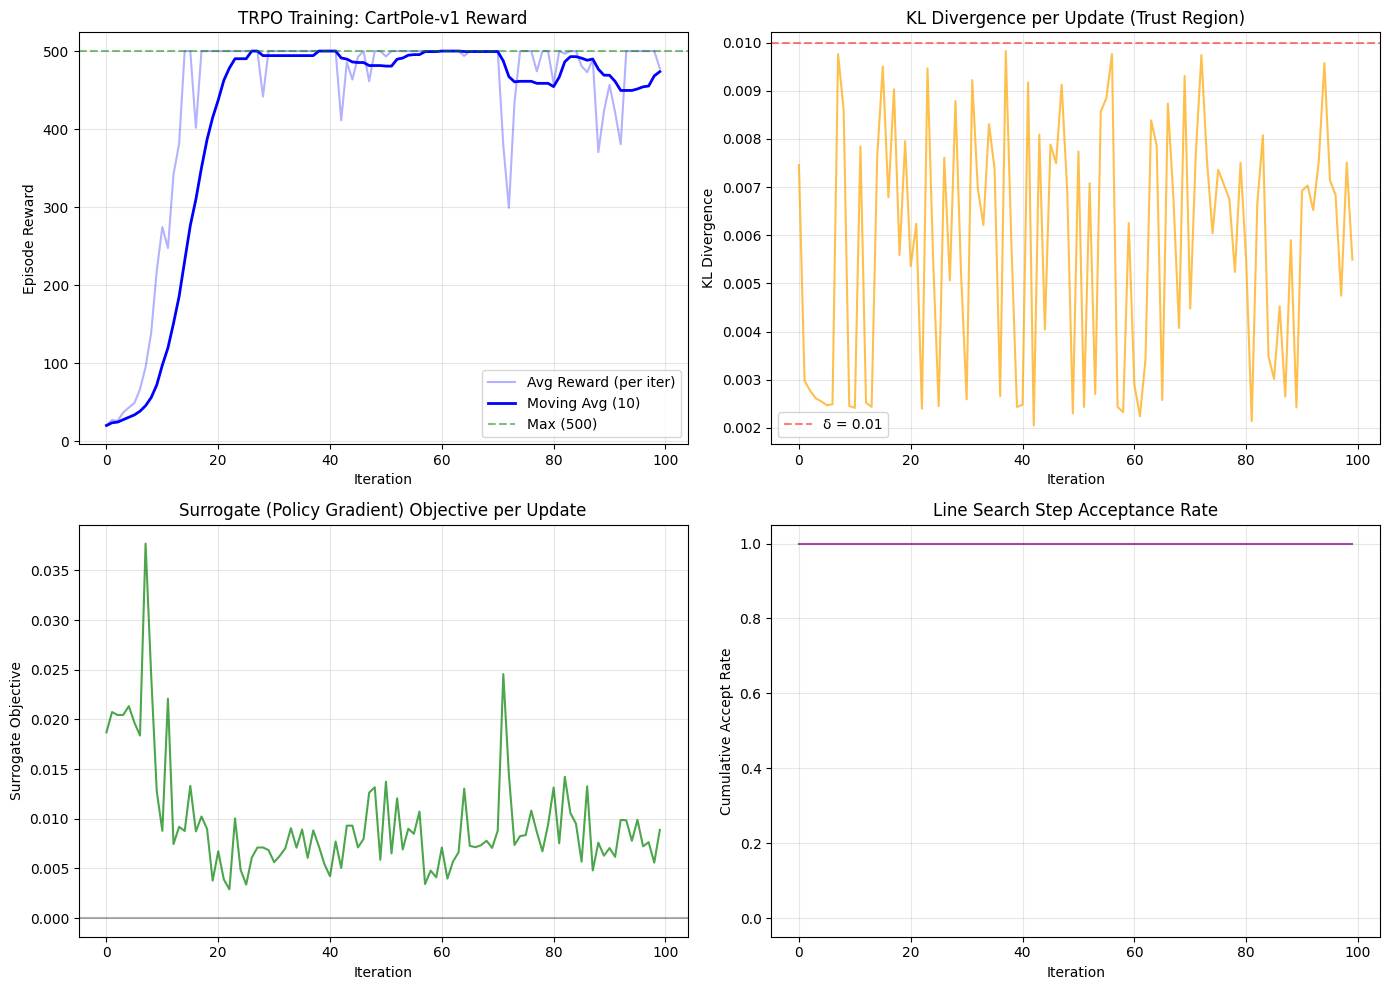

Training visualization complete.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))



# Plot 1: Episode reward

ax = axes[0, 0]

ax.plot(log_rewards, alpha=0.3, color='blue', label='Avg Reward (per iter)')

ax.plot(log_avg_rewards, color='blue', linewidth=2, label='Moving Avg (10)')

ax.axhline(y=500, color='green', linestyle='--', alpha=0.5, label='Max (500)')

ax.set_xlabel('Iteration')

ax.set_ylabel('Episode Reward')

ax.set_title('TRPO Training: CartPole-v1 Reward')

ax.legend()

ax.grid(True, alpha=0.3)



# Plot 2: KL divergence

ax = axes[0, 1]

ax.plot(log_kl, color='orange', alpha=0.7)

ax.axhline(y=MAX_KL, color='red', linestyle='--', alpha=0.5, label=f'δ = {MAX_KL}')

ax.set_xlabel('Iteration')

ax.set_ylabel('KL Divergence')

ax.set_title('KL Divergence per Update (Trust Region)')

ax.legend()

ax.grid(True, alpha=0.3)



# Plot 3: Surrogate objective

ax = axes[1, 0]

ax.plot(log_surrogate, color='green', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

ax.set_xlabel('Iteration')

ax.set_ylabel('Surrogate Objective')

ax.set_title('Surrogate (Policy Gradient) Objective per Update')

ax.grid(True, alpha=0.3)



# Plot 4: Step acceptance rate

ax = axes[1, 1]

accepted_arr = np.array(log_steps_accepted, dtype=float)

cumulative_accept = np.cumsum(accepted_arr) / (np.arange(len(accepted_arr)) + 1)

ax.plot(cumulative_accept, color='purple', alpha=0.7)

ax.set_xlabel('Iteration')

ax.set_ylabel('Cumulative Accept Rate')

ax.set_title('Line Search Step Acceptance Rate')

ax.set_ylim(-0.05, 1.05)

ax.grid(True, alpha=0.3)



plt.tight_layout()

plt.savefig('trpo_training_results.png', dpi=150, bbox_inches='tight')

plt.show()

print('Training visualization complete.')

## 12. SummaryThis notebook implemented TRPO from scratch:1. **Policy & Value Networks:** Small MLPs for the actor (softmax policy) and critic (value function)2. **GAE Advantages:** Generalized Advantage Estimation for low-variance advantage estimates3. **Surrogate Objective:** Importance-weighted advantage — the policy gradient objective to maximize4. **KL Constraint:** Trust-region constraint D̄_KL ≤ δ = 0.01, enforced via:   - **Conjugate Gradient:** Solves F⁻¹g iteratively (10 steps) using only Fisher-vector products   - **Fisher-Vector Product:** Computed via autograd (Hessian of KL), avoiding explicit matrix storage   - **Line Search:** Backtracking from the maximum step size until KL ≤ δ and surrogate > 05. **Value Function:** Updated via MSE regression on computed returns**Key insight:** TRPO's trust-region approach ensures that each policy update stays within a bounded region of policy space, preventing the destructive large steps that plague vanilla policy gradients. The conjugate gradient + Fisher-vector product approach makes this scalable to policies with thousands of parameters without ever constructing or inverting the Fisher information matrix.**Influence:** TRPO directly inspired PPO (Proximal Policy Optimization), which simplifies the trust-region enforcement into a clipped surrogate objective and is now the most widely used policy-gradient algorithm in deep RL.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
